# 01. MetroPT-3 데이터 탐색 및 가상 자산 준비

MetroPT-3 데이터셋을 탐색하고, 에이전트 테스트에 사용할 가상 설비 인터페이스와 고장 이력 DB를 준비하기 위한 주피터 노트북.

## 데이터 출처
- **MetroPT-3** (Veloso et al., 2022) — Metro APU 압축기 시계열
- 다운로드: https://archive.ics.uci.edu/dataset/791
- 다운로드 후 `../data/metropt3/` 안에 CSV 파일을 배치하세요.

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import (
    load_metropt3, SensorDB, FAILURE_WINDOWS, ANALOG_SENSORS, EQUIPMENT_REGISTRY,
)
from src.data.synthetic_history import build_history_df, save_csv

print('imports OK')

imports OK


## 1. 데이터 로드

학습/탐색 속도를 위해 1분 평균으로 다운샘플링

In [2]:
df = load_metropt3(data_dir=PROJECT_ROOT / 'data' / 'metropt3', downsample='1min')
print(f'shape: {df.shape}')
print(f'period: {df.index.min()} ~ {df.index.max()}')
df.head()

shape: (252720, 16)
period: 2020-02-01 00:00:00 ~ 2020-09-01 03:59:00


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,label
timestamp,,,,,,,,,,,,,,,,
2020-02-01 00:00:00,-0.012286,9.327429,9.311143,-0.022857,9.328000,53.521429,0.040357,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0
2020-02-01 00:01:00,-0.013000,9.260000,9.243333,-0.023333,9.259667,53.420833,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0
2020-02-01 00:02:00,-0.012667,9.198333,9.182000,-0.022333,9.199000,53.325000,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0
2020-02-01 00:03:00,-0.012333,9.136667,9.120667,-0.022667,9.136667,53.200000,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0
2020-02-01 00:04:00,-0.013000,9.075667,9.060000,-0.023000,9.075667,53.129167,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0


In [3]:
# 기본 통계
df[ANALOG_SENSORS].describe().T

,count,mean,std,min,25%,50%,75%,max
TP2,252720.0,1.380883,3.071921,-0.025667,-0.013667,-0.011714,-0.009667,10.497000
TP3,252720.0,8.980921,0.636688,0.808000,8.489667,8.953667,9.489333,10.252000
H1,252720.0,7.551330,3.169960,-0.026000,8.229667,8.739333,9.329000,10.192000
DV_pressure,252720.0,0.055390,0.357879,-0.031333,-0.022333,-0.020000,-0.017333,3.526000
Reservoirs,252720.0,8.981541,0.635934,0.790667,8.491000,8.954667,9.489357,10.253667
Oil_temperature,252720.0,62.642955,6.500479,15.400000,57.775000,62.779167,67.212500,88.795833
Motor_current,252720.0,2.056200,2.233016,0.020000,0.041071,0.045000,3.798750,6.363333


## 2. 라벨 분포

라벨은 MetroPT-3 Discription에 작성된 실제 고장 구간을 0/1로 사용 — 이상 탐지 모델 평가의 ground truth로 사용

In [4]:
n_normal = (df['label'] == 0).sum()
n_fault = (df['label'] == 1).sum()
print(f'정상: {n_normal:,}분 ({n_normal/len(df)*100:.2f}%)')
print(f'고장: {n_fault:,}분 ({n_fault/len(df)*100:.2f}%)')

print('\n정의된 고장 구간:')
for w in FAILURE_WINDOWS:
    print(f'  - {w.failure_type:10s} | {w.start} ~ {w.end} | {w.description}')

정상: 247,062분 (97.76%)
고장: 5,658분 (2.24%)

정의된 고장 구간:
  - Air Leak   | 2020-04-12 11:50:00 ~ 2020-04-12 23:30:00 | 토출부 공기 누설로 압력 회복 불가, 압축기 과작동
  - Air Leak   | 2020-04-18 00:00:00 ~ 2020-04-18 23:59:00 | 지속적 공기 누설, TP2/TP3 동시 이상
  - Air Leak   | 2020-05-29 23:30:00 ~ 2020-05-30 06:00:00 | 야간 운전 중 공기 누설 발생
  - Air Leak   | 2020-06-05 10:00:00 ~ 2020-06-07 14:30:00 | 장기간 누설, 모터 전류 상승
  - Oil Leak   | 2020-07-15 14:30:00 ~ 2020-07-15 19:00:00 | 오일 누설 의심, 오일 온도 비정상 패턴


## 3. 정상 vs 고장 시계열 비교

첫 번째 Air Leak 구간(2020-04-12)을 포함한 +-1일 구간을 시각화

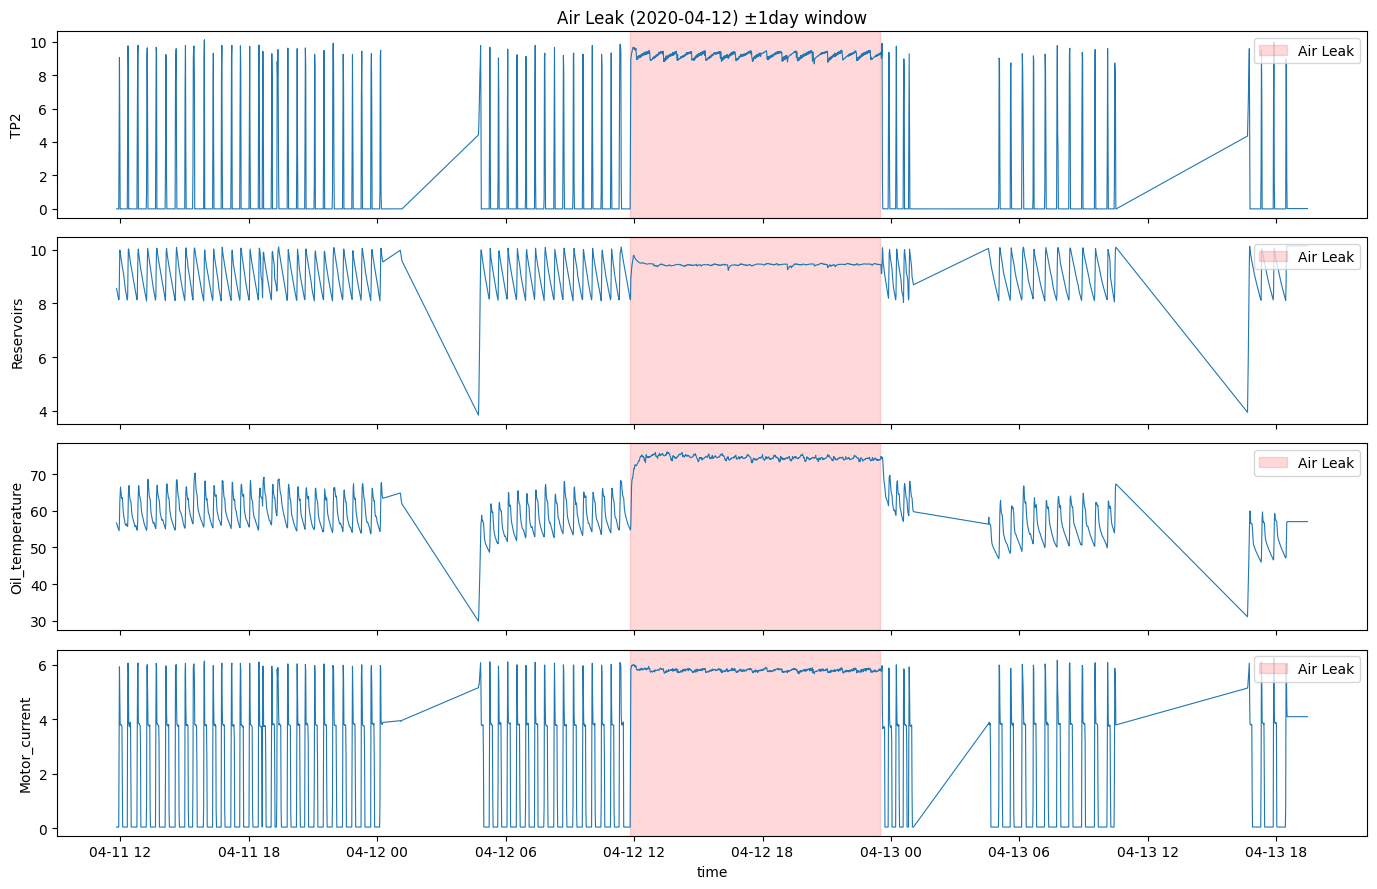

In [5]:
target = FAILURE_WINDOWS[0]
view = df.loc[target.start - pd.Timedelta(days=1) : target.end + pd.Timedelta(days=1)]

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
for ax, sensor in zip(axes, ['TP2', 'Reservoirs', 'Oil_temperature', 'Motor_current']):
    ax.plot(view.index, view[sensor], lw=0.8)
    ax.axvspan(target.start, target.end, color='red', alpha=0.15, label='Air Leak')
    ax.set_ylabel(sensor)
    ax.legend(loc='upper right')
axes[0].set_title(f'Air Leak ({target.start.date()}) ±1day window')
axes[-1].set_xlabel('time')
plt.tight_layout()
plt.show()

## 4. SensorDB — 가상 멀티 설비 합성 데이터 생성

MetroPT-3는 단일 APU 데이터지만, 에이전트 테스트를 위해 시간 오프셋 분할로 3개의 가상 설비(APU-01/02/03) 데이터를 생성

In [6]:
db = SensorDB(df=df)
for eid in db.equipment_ids:
    info = db.info(eid)
    print(f"{eid:8s} | {info['name']:15s} | {info['location']}")

APU-01   | 1호 APU 압축기      | Line A 차량기지
APU-02   | 2호 APU 압축기      | Line B 차량기지
APU-03   | 3호 APU 압축기      | Line C 차량기지


In [ ]:
# 특정 설비, 특정 시간 범위 조회
snippet = db.query(
    equipment_id='APU-03',
    start='2020-06-11 11:00',
    end='2020-06-13 00:00',
)
print(snippet.shape)
snippet.head()

(1371, 8)


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,label
timestamp,,,,,,,,
2020-06-11 11:00:00,-0.013000,9.684000,9.671333,-0.022667,9.682333,64.595833,3.801250,0.0
2020-06-11 11:01:00,-0.012333,9.570000,9.556667,-0.022667,9.568667,63.450000,3.791667,0.0
2020-06-11 11:02:00,-0.013333,9.434333,9.421000,-0.023333,9.431667,63.233333,3.784583,0.0
2020-06-11 11:03:00,-0.012667,9.350667,9.339000,-0.023333,9.349333,62.887500,3.790000,0.0
2020-06-11 11:04:00,-0.012333,9.272667,9.262000,-0.023000,9.273667,62.345833,0.672083,0.0


## 5. 가상 고장 이력 CSV 생성

실제 산업현장의 CMMS(Computerized Maintenance Management System)에 누적되는 고장 사례 텍스트를 모사

RAG 검색용 데이터로 활용

라벨과의 관계**: 각 이력의 'date' / 'equipment_id'는 SensorDB 가상 설비 오프셋(APU-01: +0d, APU-02: +30d, APU-03: +60d)을 적용한 외부 표시 시간 기준으로 라벨 구간 직전/직후로 배치. 즉 에이전트가 "APU-03 6월 11일 압력 이상" 진단 요청 시, RAG가 끌어오는 과거 사례(예: INC-2020-0607, 4일 전 동일 라인 누설)는 자연스럽게 같은 사건의 전조를 가리킴.

In [8]:
history_df = build_history_df()
print(f'총 {len(history_df)}건')
history_df[['case_id', 'date', 'equipment_id', 'diagnosis', 'downtime_min']]

총 8건


,case_id,date,equipment_id,diagnosis,downtime_min
0,INC-2020-0317,2020-03-17 10:20:00,APU-01,센서 드리프트 (Sensor Drift),25
1,INC-2020-0405,2020-04-05 09:30:00,APU-01,공기 누설 초기 (Air Leak — Minor),30
2,INC-2020-0508,2020-05-08 03:15:00,APU-02,공기 누설 (Air Leak),120
3,INC-2020-0607,2020-06-07 03:00:00,APU-03,공기 누설 + 밸브 이상 의심,180
4,INC-2020-0701,2020-07-01 11:45:00,APU-02,공기 누설 + 압축기 부하 증가,50
5,INC-2020-0712,2020-07-12 16:40:00,APU-01,오일 누설 전조 (Oil Leak — Suspect),35
6,INC-2020-0801,2020-08-01 22:40:00,APU-03,공기 누설 재발 (Air Leak — Recurring),95
7,INC-2020-0910,2020-09-10 06:00:00,APU-03,오일 누설 (Oil Leak),60


In [ ]:
# CSV로 저장 -> 03_rag_setup.ipynb에서 인덱싱 시 사용
out_path = save_csv(PROJECT_ROOT / 'data' / 'history' / 'failure_history.csv')
print(f'saved: {out_path}')

saved: d:\Work\study_full_data\log_anomaly_dectetion_pipeline\log-anomaly-detection\.claude\worktrees\epic-turing-62c439\llm_agent_phm\data\history\failure_history.csv
